# Hyperparameter sensitivity — 04 connectivity methods

One curve per swept hyperparameter, for each of the five arms: 16-task
non-stationary multi-MNIST, 800,000 steps, 5 vmapped seeds per cell.

**Each point is that parameter value at its own best setting of everything
else** — not an average over the rest of the grid. Marginalising would punish a
value that works only in a narrow corner, which is the opposite of what a
sensitivity curve is for: the question is "how good can this value be made",
not "how good is it on average". Concretely, for a point at
`evolve_frequency=250` we take the minimum asymptotic loss over every
(width, learning rate) pair at that frequency.

Lower is better throughout — the y axis is loss.

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from multi_mnist.analysis import (
    asymptotic_metric, filter_sweep, load_export, normalize_columns,
    plot_sensitivity, save_fig, set_style,
)

%matplotlib inline
set_style()

## Sweeps, axes and cells

Each arm spans one or two Comet sweep names: the v2 grid, plus a `v2b` top-up
that re-ran one width after the original sweep lost its remaining assignments.
`filter_sweep` merges them and `dedupe_trials` keeps one trial per cell,
preferring trials that logged every expected period (a divergence counts as
finished, since stopping early on divergence is a completed measurement).
That is what collapses both the top-up overlap and the failed retries.

In [32]:
PROJECT = 'paper-weight-pruning-connectivity-sweep'

SWEEPS = {
    'SET':           ['04_set_n16_v2', '04_set_n16_v2b_h1024'],
    'DEEP-R':        ['04_deep_r_n16_v2', '04_deep_r_n16_v2b_h768'],
    'Static sparse': ['04_static_sparse_n16_v2'],
    'Dense':         ['04_dense_n16_v2'],
    'Block-sparse':  ['04_block_sparse_n16_v2'],
}

LR = 'optimizer.learning_rate'

# The swept axes of each arm. The learning rate is last everywhere; the arms
# with no other axis are tuned on it alone.
AXES = {
    'SET':           ['target_hidden_units', 'algorithm.evolve_frequency', LR],
    'DEEP-R':        ['target_hidden_units', 'algorithm.l1',
                      'algorithm.noise_ratio', LR],
    'Static sparse': ['target_hidden_units', LR],
    'Dense':         [LR],
    'Block-sparse':  [LR],
}

# How each axis reads on an x scale. The learning-rate grid is powers of two;
# l1 spans decades; the rest are plotted linearly -- widths include 768 and
# noise_ratio includes 0, neither of which survives a log axis.
AXIS_STYLE = {
    LR:                          dict(label='Step-size', log_base=2),
    'target_hidden_units':       dict(label='Hidden units', log_base=None),
    'algorithm.evolve_frequency':dict(label='Evolve frequency (steps)', log_base=None),
    'algorithm.l1':              dict(label=r'$\alpha$  (L1)', log_base=10),
    'algorithm.noise_ratio':     dict(label=r'Noise ratio  $\sqrt{2\eta T}/\eta\alpha$',
                                      log_base=None),
}

FIG_DIR = '../figures/generated'   # output, rewritten on every re-run

TAIL_FRAC = 0.10   # asymptotic = mean over the final 10% of logged periods

In [33]:
# Run once to fetch from Comet, then leave commented out.
# from multi_mnist.analysis import download_project
# download_project(PROJECT, output_dir='data')

cfg_all, run_all = load_export(PROJECT, data_dir='data')
cfg_all = normalize_columns(cfg_all)
print(f'{len(cfg_all)} trials, {len(run_all)} metric rows')

569 trials, 266874 metric rows


## One row per grid cell

`asymptotic_metric` averages the final `TAIL_FRAC` of each trial's logged loss,
nulls any trial flagged diverged, and aggregates with `skipna=False` — so a
single bad seed makes the whole cell NaN rather than quietly averaging away.
NaNs are kept from here on. They drop out of the "best over the rest" step
because a NaN can never be the minimum, and a parameter value whose every
alternative is NaN stays NaN and leaves a visible gap in the curve.

In [34]:
def cell_table(method):
    """Asymptotic loss for every cell of one arm's grid."""
    axes = AXES[method]
    cfg, run = filter_sweep(cfg_all, run_all, SWEEPS[method], cell_cols=axes)
    # asymptotic_metric always groups by the learning rate, so pass the others.
    others = [a for a in axes if a != LR]
    return asymptotic_metric(cfg, run, 'loss', others, tail_frac=TAIL_FRAC)


cells_by_method = {m: cell_table(m) for m in SWEEPS}

for m, tab in cells_by_method.items():
    n_nan = int(tab['_metric'].isna().sum())
    print(f'{m:14s} {len(tab):3d} cells, {n_nan:3d} NaN '
          f'(diverged or a NaN seed), best loss {tab["_metric"].min():.3f}')

SET             64 cells,   0 NaN (diverged or a NaN seed), best loss 19.230
DEEP-R         144 cells,   8 NaN (diverged or a NaN seed), best loss 20.314
Static sparse   16 cells,   0 NaN (diverged or a NaN seed), best loss 26.007
Dense            4 cells,   0 NaN (diverged or a NaN seed), best loss 34.690
Block-sparse     4 cells,   1 NaN (diverged or a NaN seed), best loss 8.569


## Sensitivity: best-of-the-rest at each value

For each value of the axis, the minimum over every other hyperparameter.

In [35]:
def sensitivity(method, x_col):
    """Best (lowest) asymptotic loss achievable at each value of ``x_col``."""
    tab = cells_by_method[method]
    # min() skips NaN, so a diverged alternative does not hide a good one;
    # an all-NaN value yields NaN and breaks the line, which is the honest
    # rendering of "nothing at this setting finished".
    out = (tab.groupby(x_col, dropna=False)['_metric']
              .min().reset_index().sort_values(x_col))
    return out


def plot_method(method, fig_width=4.0, ylim=None):
    axes = AXES[method]
    fig, axs = plt.subplots(1, len(axes), figsize=(fig_width * len(axes), 3.4),
                            squeeze=False)
    for ax, col in zip(axs[0], axes):
        style = AXIS_STYLE[col]
        sub = sensitivity(method, col)
        plot_sensitivity(
            sub, ax=ax, x_col=col, y_col='_metric',
            xlabel=style['label'], ylabel='Asymptotic loss',
            log_base=style['log_base'], ylim=ylim)
        if not style['log_base']:
            # plot_sensitivity only pins ticks on a log axis; on a linear one
            # matplotlib would invent its own (300, 400, ...) and hide which
            # values were actually run.
            ticks = sorted(sub[col].dropna().unique())
            ax.set_xticks(ticks)
            ax.set_xticklabels([f'{t:g}' for t in ticks])
    fig.suptitle(method, y=1.02)
    fig.tight_layout()
    return fig, axs

### SET

Three axes: the width the budget is spread over, how often the
prune-and-regrow event fires (ζ is derived from it, holding the paper's
per-example rewiring rate fixed), and the step-size.

In [ ]:
fig, _ = plot_method('SET')
save_fig('04_sensitivity_set', fig_dir=FIG_DIR)

### DEEP-R

Four axes. `l1` is the strength of the pull toward zero that drives pruning,
and `noise_ratio` is the Langevin noise scaled to that pull — 0 turns the noise
off entirely, leaving deterministic sign-flip pruning.

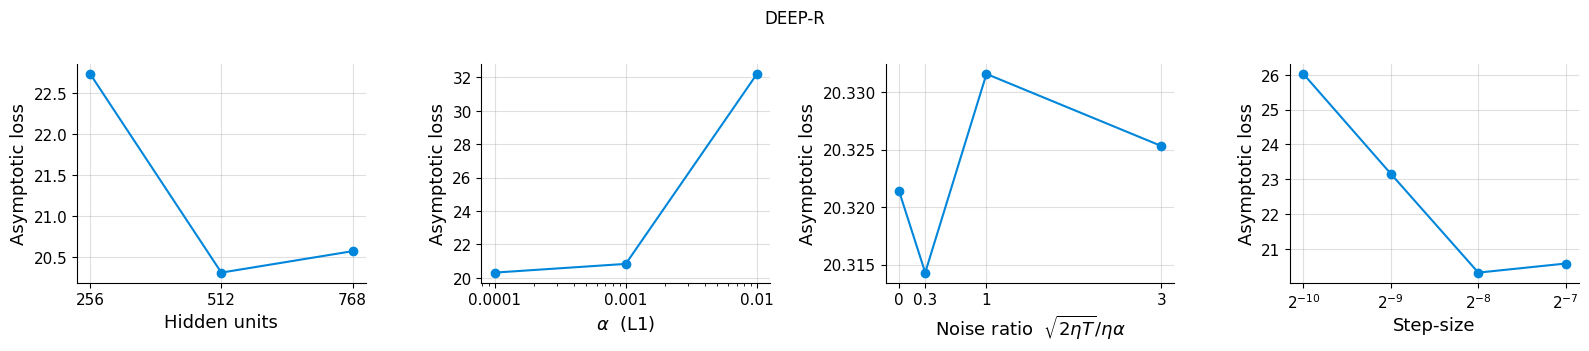

In [ ]:
fig, _ = plot_method('DEEP-R')
save_fig('04_sensitivity_deep_r', fig_dir=FIG_DIR)

### Static sparse — SET's initialization, frozen

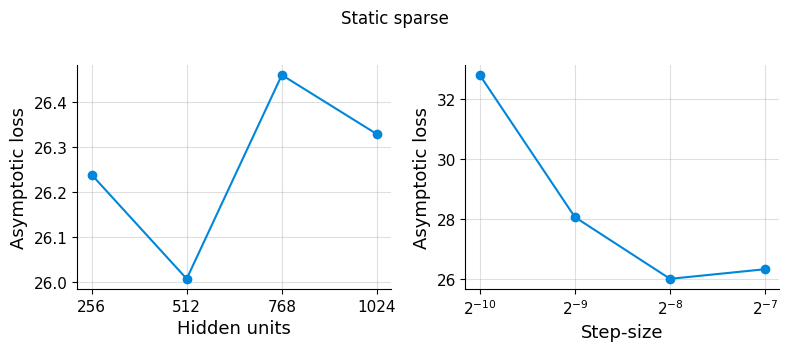

In [ ]:
fig, _ = plot_method('Static sparse')
save_fig('04_sensitivity_static_sparse', fig_dir=FIG_DIR)

### The two fixed-connectivity arms

Both are tuned on the step-size alone: block-sparse sits at the width that
defines the shared budget, and dense's width is derived from that budget
(16 units, since a fully connected unit costs 12,704 weights at 16 tasks).
Note the two use different step-size windows — dense diverges above 2⁻⁹.

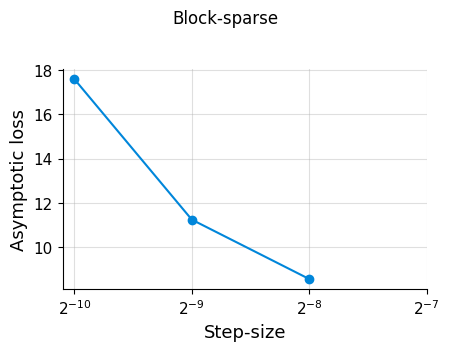

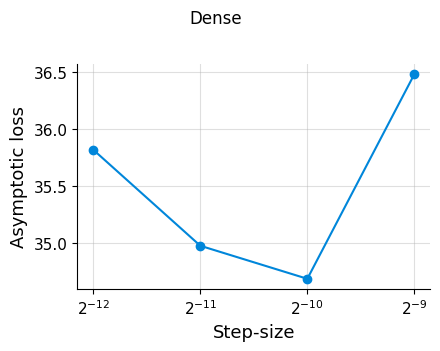

In [ ]:
for m in ('Block-sparse', 'Dense'):
    fig, _ = plot_method(m, fig_width=4.6)
    save_fig(f'04_sensitivity_{m.lower().replace("-", "_")}', fig_dir=FIG_DIR)

## All arms on one step-size axis

The one axis every arm shares, so the five are directly comparable.

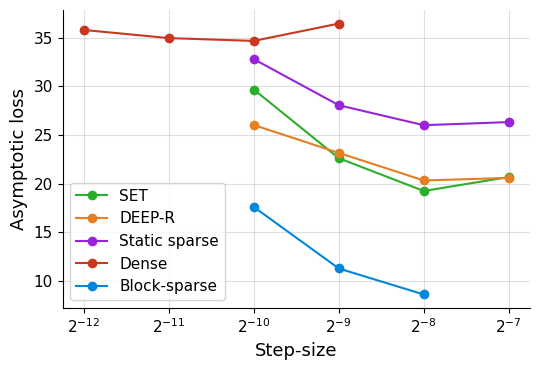

In [ ]:
from multi_mnist.analysis import get_color_palette

fig, ax = plt.subplots(figsize=(5.5, 3.8))
# A class->color mapping, so SET, DEEP-R, dense and block-sparse keep the
# colors they carry in the rest of the paper.
colors = get_color_palette(list(SWEEPS))
for method in SWEEPS:
    sub = sensitivity(method, LR)
    ax.plot(sub[LR], sub['_metric'], '-o', color=colors[method], label=method)
ax.set_xscale('log', base=2)
ticks = sorted(set().union(*[set(sensitivity(m, LR)[LR].dropna()) for m in SWEEPS]))
ax.set_xticks(ticks)
ax.set_xticklabels([f'$2^{{{int(np.log2(v))}}}$' for v in ticks])
ax.set_xlabel('Step-size')
ax.set_ylabel('Asymptotic loss')
ax.grid(True, alpha=0.4)
ax.legend(loc='best')
fig.tight_layout()
save_fig('04_sensitivity_all_step_size', fig_dir=FIG_DIR)

## Best cell per arm

The winning configuration behind each curve's minimum.

In [ ]:
rows = []
for method, axes in AXES.items():
    tab = cells_by_method[method]
    best = tab.loc[tab['_metric'].idxmin()]
    rows.append({'arm': method, 'loss': round(float(best['_metric']), 4),
                 **{a.split('.')[-1]: best[a] for a in axes}})
pd.DataFrame(rows).set_index('arm')

,loss,target_hidden_units,evolve_frequency,learning_rate,l1,noise_ratio
arm,,,,,,
SET,19.2304,256.0,1000.0,0.003906,NaN,NaN
DEEP-R,20.3143,512.0,NaN,0.003906,0.0001,0.3
Static sparse,26.0071,512.0,NaN,0.003906,NaN,NaN
Dense,34.6903,NaN,NaN,0.000977,NaN,NaN
Block-sparse,8.5694,NaN,NaN,0.003906,NaN,NaN


## v3 — SET and DEEP-R at a fixed step-size

v2 left both arms with their best cell on a grid edge, so v3 re-centres the
windows: SET's width moves down to 64-512 and its evolve frequency up to
500-4000, DEEP-R's `l1` extends down to 0. The step-size is fixed at 2^-8,
interior for every arm in v2, and DEEP-R's `noise_ratio` is pinned at the
paper's 1.0 after returning a null at both horizons.

In [ ]:
V3_SWEEPS = {'SET': ['04_set_n16_v3'], 'DEEP-R': ['04_deep_r_n16_v3']}

# The step-size is fixed in v3, so it is not an axis here.
V3_AXES = {
    'SET':    ['target_hidden_units', 'algorithm.evolve_frequency'],
    'DEEP-R': ['target_hidden_units', 'algorithm.l1'],
}


def v3_cell_table(method):
    axes = V3_AXES[method]
    cfg, run = filter_sweep(cfg_all, run_all, V3_SWEEPS[method],
                            cell_cols=axes + [LR])
    return asymptotic_metric(cfg, run, 'loss', axes, tail_frac=TAIL_FRAC)


v3_by_method = {m: v3_cell_table(m) for m in V3_SWEEPS}

for m, tab in v3_by_method.items():
    n_nan = int(tab['_metric'].isna().sum())
    print(f'{m:8s} {len(tab):2d} cells, {n_nan} NaN, best loss {tab["_metric"].min():.3f}')

In [ ]:
def plot_method_v3(method, fig_width=4.0, ylim=None):
    """The same sensitivity view as plot_method, over the v3 grid."""
    axes = V3_AXES[method]
    tab = v3_by_method[method]
    fig, axs = plt.subplots(1, len(axes), figsize=(fig_width * len(axes), 3.4),
                            squeeze=False)
    for ax, col in zip(axs[0], axes):
        style = AXIS_STYLE[col]
        sub = (tab.groupby(col, dropna=False)['_metric']
                  .min().reset_index().sort_values(col))
        if style['log_base']:
            # A log axis cannot show 0, and leaving it in collapses the scale
            # so the decades that matter overlap. l1=0 is reported separately.
            sub = sub[sub[col] > 0]
        plot_sensitivity(
            sub, ax=ax, x_col=col, y_col='_metric',
            xlabel=style['label'], ylabel='Asymptotic loss',
            log_base=style['log_base'], ylim=ylim)
        if not style['log_base']:
            ticks = sorted(sub[col].dropna().unique())
            ax.set_xticks(ticks)
            ax.set_xticklabels([f'{t:g}' for t in ticks])
    fig.suptitle(f'{method}  (v3, step-size $2^{{-8}}$)', y=1.02)
    fig.tight_layout()
    return fig, axs

### SET

In [ ]:
fig, _ = plot_method_v3('SET')
save_fig('04_sensitivity_set_v3', fig_dir=FIG_DIR)

### DEEP-R

`l1` is plotted on a log axis, so the `l1`=0 cell cannot appear on it; its
value is printed below the figure.

In [ ]:
fig, _ = plot_method_v3('DEEP-R')
save_fig('04_sensitivity_deep_r_v3', fig_dir=FIG_DIR)

tab = v3_by_method['DEEP-R']
zero = tab[tab['algorithm.l1'] == 0]['_metric']
if len(zero):
    print(f'l1 = 0 (off the log axis): best asymptotic loss {zero.min():.3f}')

# Finals — 30 seeds at each arm's best cell

800,000 steps, 30 seeds, all five arms at the same 203,264-connection budget.
Each arm ran as two 15-seed halves (`seed_offset` 101 and 116); the halves are
rejoined along the seed axis, so every interval below is over 30 seeds.

In [ ]:
from multi_mnist.analysis import (
    fetch_per_seed_arrays, get_color_palette, plot_ci_curve, stack_per_seed,
)

BEST_PROJECT = 'paper-weight-pruning-connectivity-best'

BEST_SWEEPS = {
    'Dense':         '04_dense_n16_best',
    'Block-sparse':  '04_block_sparse_n16_best',
    'Static sparse': '04_static_sparse_n16_best',
    'SET':           '04_set_n16_best',
    'DEEP-R':        '04_deep_r_n16_best',
}

# Connectivity never changes in these three, so their path purity is a
# constant and is drawn as a rule rather than a curve.
FIXED_CONNECTIVITY = ('Dense', 'Block-sparse', 'Static sparse')

LOG_FREQ = 1000          # steps per logged period
ARM_COLORS = get_color_palette(list(BEST_SWEEPS))

best_cfg, best_run = load_export(BEST_PROJECT, data_dir='data')
best_cfg = normalize_columns(best_cfg)
print(f'{len(best_cfg)} trials, {len(best_run)} metric rows')

In [ ]:
def best_curves(arm):
    """Per-seed loss and accuracy for one arm, both halves pooled.

    seed_offset is in cell_cols so a half that was run twice dedupes to one
    trial; without it a duplicated half would contribute its 15 seeds twice and
    narrow the interval on seeds that are not independent.
    """
    cfg, _ = filter_sweep(best_cfg, best_run, [BEST_SWEEPS[arm]],
                          cell_cols=['seed_offset'])
    run_ids = cfg['run_id'].tolist()
    assets = fetch_per_seed_arrays(run_ids, cache_dir='data/per_seed_cache')
    return stack_per_seed(assets, run_ids)      # (periods, seeds) each


def best_path_purity(arm):
    """Mean path purity per period. Logged per trial, not per seed, so this
    is a mean over halves and carries no interval."""
    cfg, run = filter_sweep(best_cfg, best_run, [BEST_SWEEPS[arm]],
                            cell_cols=['seed_offset'])
    series = [g['path_purity'].dropna().to_numpy()
              for _, g in run.groupby('run_id') if g['path_purity'].notna().any()]
    if not series:
        return None
    n = min(len(s) for s in series)
    return np.stack([s[:n] for s in series]).mean(axis=0)


curves = {arm: best_curves(arm) for arm in BEST_SWEEPS}
purity = {arm: best_path_purity(arm) for arm in BEST_SWEEPS}

for arm, (losses, accs) in curves.items():
    print(f'{arm:14s} {accs.shape[1]:2d} seeds, {accs.shape[0]} periods, '
          f'final acc {np.nanmean(accs[-1]):.4f}')

### Loss and accuracy

In [ ]:
def plot_metric(which, ylabel, savename, ylim=None):
    """One arm per line, mean and 95% t-interval over 30 seeds."""
    set_style('2-col')
    fig, ax = plt.subplots()
    for arm in BEST_SWEEPS:
        losses, accs = curves[arm]
        arr = losses if which == 'loss' else accs
        steps = np.arange(arr.shape[0]) * LOG_FREQ
        plot_ci_curve(steps, arr, label=arm, color=ARM_COLORS[arm], ax=ax)
    ax.set_xlabel('Step')
    ax.set_ylabel(ylabel)
    if ylim:
        ax.set_ylim(*ylim)
    ax.ticklabel_format(axis='x', style='sci', scilimits=(0, 0), useMathText=True)
    # Above the axes rather than inside: every interior corner of these panels
    # has a curve running through it, and a legend there hides data.
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.005),
               ncol=3, frameon=False, handlelength=1.6, columnspacing=1.4)
    fig.tight_layout(rect=(0, 0, 1, 0.84))
    save_fig(savename, fig_dir=FIG_DIR)
    return fig


plot_metric('loss', 'Loss', '04_best_loss')
plot_metric('accuracy', 'Accuracy', '04_best_accuracy', ylim=(0, 1.0))
plt.show()


### Path purity

The fraction of input-to-output paths that stay within one task. Dense and
static sparse sit at 1/16 = 0.0625, which is chance at 16 tasks; block-sparse
is 1.0 by construction. All three are fixed connectivity, so they are drawn as
dotted rules. Only SET and DEEP-R move, and the question is how far.

In [ ]:
set_style('2-col')
fig, ax = plt.subplots()

# Dense and static sparse both sit at exactly 1/16, so a single dotted style
# would draw one on top of the other. Offsetting the dash phase interleaves
# them and both stay visible.
FIXED_DASH = {'Dense': (0, (1, 4)), 'Block-sparse': (0, (1, 4)),
              'Static sparse': (2, (1, 4))}

for arm in BEST_SWEEPS:
    pp = purity[arm]
    if pp is None:
        continue
    if arm in FIXED_CONNECTIVITY:
        ax.axhline(float(np.mean(pp)), ls=FIXED_DASH[arm], lw=2.4,
                   color=ARM_COLORS[arm], label=f'{arm} ({np.mean(pp):.3f})')
    else:
        steps = np.arange(len(pp)) * LOG_FREQ
        ax.plot(steps, pp, color=ARM_COLORS[arm],
                label=f'{arm} ({pp[-1]:.3f})')

# Chance is 1/n_tasks: a path drawn at random stays inside one task this often.
ax.axhline(1 / 16, color='0.55', lw=1.0, zorder=0)
ax.text(0.02, 1 / 16, ' chance', ha='left', va='bottom', fontsize=13,
        color='0.45', transform=ax.get_yaxis_transform())

ax.set_yscale('log')
ax.set_ylim(0.05, 1.5)
ax.set_xlabel('Step')
ax.set_ylabel('Path purity')
ax.ticklabel_format(axis='x', style='sci', scilimits=(0, 0), useMathText=True)
# The band between the two groups is empty, so the legend costs no plot area.
ax.legend(loc='center', frameon=False, ncol=2, fontsize=13,
          handlelength=1.8, columnspacing=1.2)
fig.tight_layout()
save_fig('04_best_path_purity', fig_dir=FIG_DIR)
plt.show()

for arm in BEST_SWEEPS:
    pp = purity[arm]
    if pp is not None and arm not in FIXED_CONNECTIVITY:
        print(f'{arm:8s} path purity {pp[0]:.4f} -> {pp[-1]:.4f} '
              f'({pp[-1] / (1 / 16):.2f}x chance, block-sparse is 16x)')


### Final numbers

In [ ]:
rows = []
for arm in BEST_SWEEPS:
    losses, accs = curves[arm]
    tail = max(1, int(TAIL_FRAC * accs.shape[0]))
    a, l = accs[-tail:], losses[-tail:]
    rows.append({
        'arm': arm, 'seeds': accs.shape[1],
        'accuracy': round(float(np.nanmean(a)), 4),
        'acc sd (seeds)': round(float(np.nanstd(np.nanmean(a, axis=0), ddof=1)), 4),
        'loss': round(float(np.nanmean(l)), 3),
        'path purity': round(float(purity[arm][-1]), 4),
    })
pd.DataFrame(rows).set_index('arm')